# Практическое занятие № 2
## «Решение задачи классификации. Прогнозирование выживаемости пассажиров титаника»

1. Для выполнения задания использовать данные – https://www.kaggle.com/competitions/titanic/data .
2. Загрузить и исследовать данные. Вывести размерность данных, основные описательные статистики, типы данных для признаков.
3. Осуществить проверку данных на наличие пропущенных значений. Если пропущенные значения есть – выбрать стратегию работы с пропусками для каждого отдельного признака и избавиться от них.
4. Удалить из данных признаки: PassengerId, Name, Ticket.
5. На основе признаков SibSp и Parch создать категориальный признак TravelAlone, который определяет путешествовал ли человек в одиночку или нет.
6. Используя функцию value_counts(), посчитать количество человек каждого пола. С помощью countplot из seaborn визуализировать эти данные.
7. С помощью barplot из seaborn визуализировать влияние признака пол на выживаемость пассажиров. Построить гистограмму количества погибших и выживших пассажиров среди мужчин и женщин (использовать countplot из seaborn).
8. Посчитать количество пассажиров в зависимости от признака Pclass. Построить гистограмму по этим данным (countplot).
9. Исследовать влияние признака Pclass на выживаемость, визуализировать данные на основе barplot. Построить гистограмму количества погибших и выживших пассажиров, сгруппировав данные по признаку Pclass (использовать countplot из seaborn).
10. Исследовать выживаемость пассажиров в зависимости от возраста.
11. Построить lmplot из библиотеки seaborn, указав следующие аргумены (x='Age',y='Survived'). Сделать вывод по полученной визуализации.
12. Вывести количество пассажиров по признаку «Emabarked», визуализировать с помощью countplot.
13. Исследовать влияние признака «Embarked» на выживаемость, визуализировать с помощью barplot. Построить гистограмму количества погибших и выживших пассажиров, сгруппировав данные по признаку «Embarked» (использовать countplot из seaborn).
14. Вывести количество пассажиров на основе признака «TravelAlone», визуализировать данные с помощью countplot.
15. Исследовать влияние признака «TravelAlone» на выживаемость, визуализировать с помощью с помощью barplot.
16. По данным построить матрицу корреляций. Сделать выводы на основании полученных значений.
17. Для категориальных признаков «Sex» и «Embarked» выполнить Label-кодирование.
18. Разделить данные на обучающую и тестовую выборки.
19. Построить различные модели для прогноза выживаемости пассажира (не менее 3 моделей). Выбрать метрику и сравнить по ней построенные модели.
20. Для каждой модели построить матрицу ошибок (confusion_matrix) и classification_report по тестовой выборке.
21. Для лучшей модели подобрать оптимальные значения параметров с помощью поиска по сетке (GridSearchCV).
22. На основе лучшей модели с оптимальными параметрами сделать прогнозы на новых данных (файл test.csv).


## 🚢 Словарь данных о "Титанике"

| Переменная | Определение | Ключ / Примечания |
| :--- | :--- | :--- |
| **survival** | Выживание | $0 = \text{Нет}, 1 = \text{Да}$ |
| **pclass** | Класс билета | $1 = \text{1-й (Высший), } 2 = \text{2-й (Средний), } 3 = \text{3-й (Низший)}$ |
| **sex** | Пол | |
| **Age** | Возраст в годах | Дробный, если $< 1$. $\text{xx.5}$ - оценочный возраст. |
| **sibsp** | Количество братьев, сестер / супругов на борту | **Siblings**: брат, сестра, сводный брат, сводная сестра. **Spouse**: муж, жена (любовницы и женихи игнорировались). |
| **parch** | Количество родителей / детей на борту | **Parent**: мать, отец. **Child**: дочь, сын, падчерица, пасынок. (Дети с нянями: $\text{parch}=0$). |
| **ticket** | Номер билета | |
| **fare** | Тариф пассажира | |
| **cabin** | Номер каюты | |
| **embarked** | Порт посадки | $C = \text{Шербур}, Q = \text{Квинстаун}, S = \text{Саутгемптон}$ |

---

Могу ли я помочь вам с анализом этих данных или с чем-нибудь еще, связанным с этим набором данных?

In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [130]:
train_df = pd.read_csv('titanic_train.csv')
test_df = pd.read_csv('titanic_test.csv')

In [131]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [132]:
print(f"Размерность данных: {train_df.shape}")
print("\nТипы данных:")
print(train_df.info())
print("\nпропуски")
print(train_df.isnull().sum())
print("\nОсновные статистики:")
display(train_df.describe())

Размерность данных: (891, 12)

Типы данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

пропуски
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare          

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [133]:
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

if 'Cabin' in train_df.columns: train_df.drop('Cabin', axis=1, inplace=True)

print("\nПропуски после обработки:")
print(train_df.isnull().sum())


Пропуски после обработки:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [134]:
cols_to_drop = ['PassengerId', 'Name', 'Ticket']
train_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')


In [135]:
train_df['TravelAlone'] = np.where((train_df['SibSp'] + train_df['Parch']) > 0, 0, 1)

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,TravelAlone
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,0
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,0
4,0,3,male,35.0,0,0,8.0500,S,1


Sex
male      577
female    314
Name: count, dtype: int64


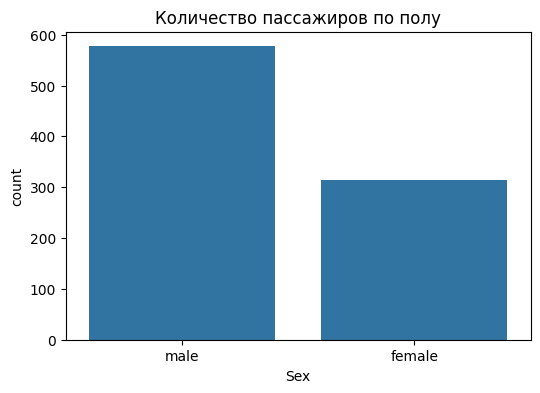

In [ ]:
# Количество человек каждого пола 
print(train_df['Sex'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', data=train_df)
plt.title('Количество пассажиров по полу')
plt.show()

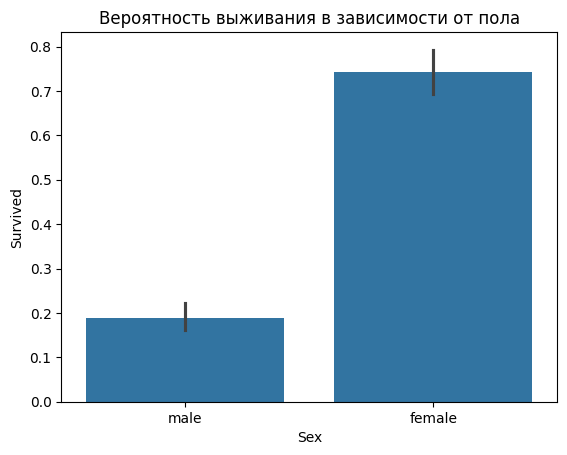

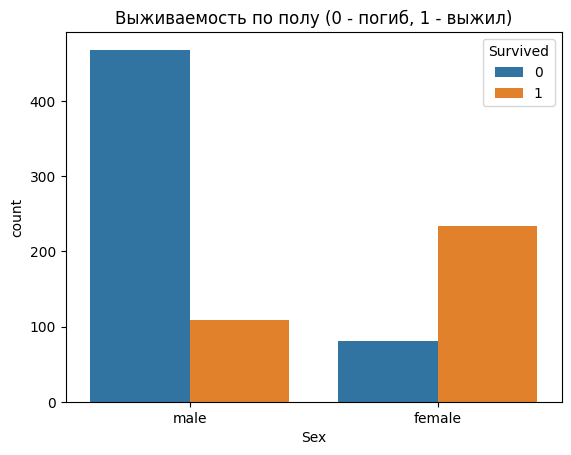

In [137]:
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title('Вероятность выживания в зависимости от пола')
plt.show()

sns.countplot(x='Sex', hue='Survived', data=train_df)
plt.title('Выживаемость по полу (0 - погиб, 1 - выжил)')
plt.show()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


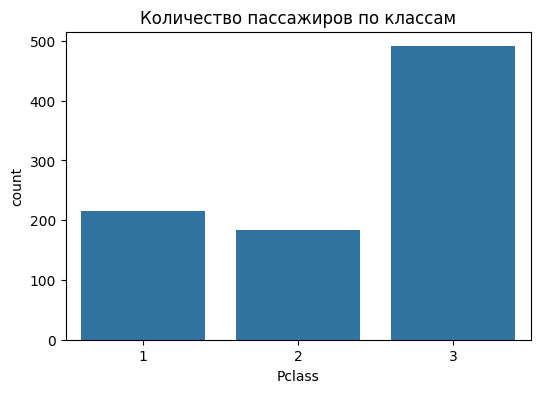

In [138]:
print(train_df['Pclass'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', data=train_df)
plt.title('Количество пассажиров по классам')
plt.show()

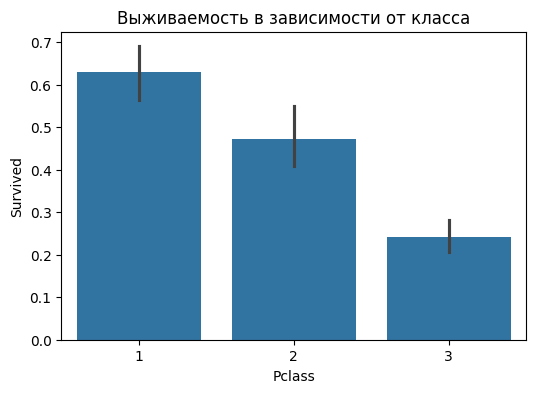

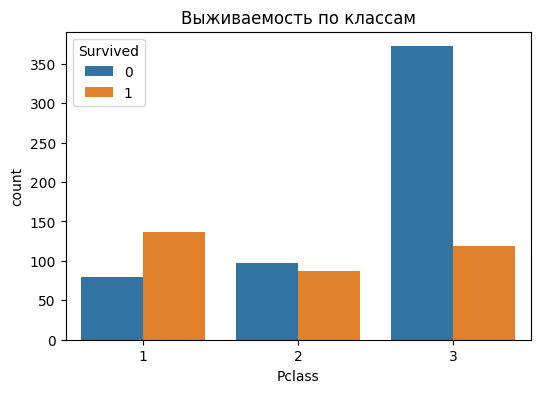

In [ ]:
# Влияние Pclass на выживаемость (barplot) 
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title('Выживаемость в зависимости от класса')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=train_df)
plt.title('Выживаемость по классам')
plt.show()

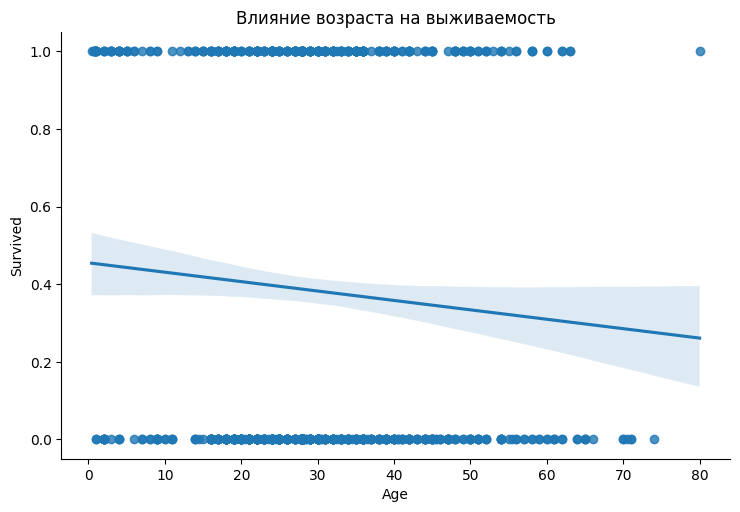

In [140]:
sns.lmplot(x='Age', y='Survived', data=train_df, height=5, aspect=1.5)
plt.title('Влияние возраста на выживаемость')
plt.show()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


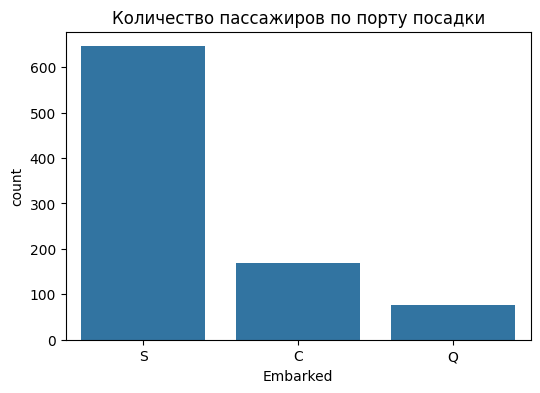

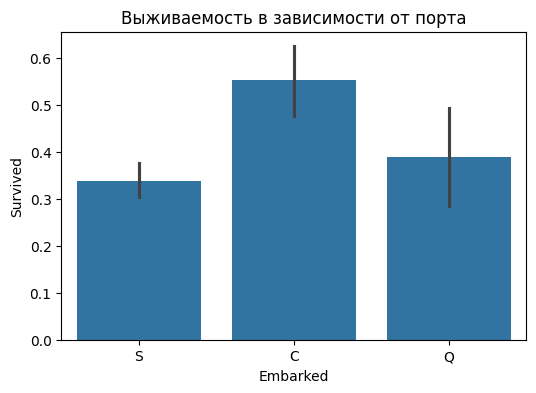

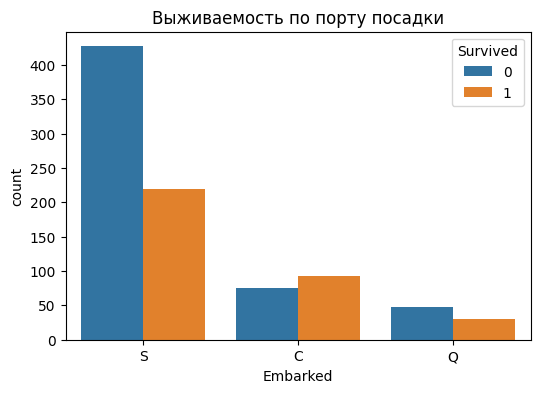

In [141]:
# Количество пассажиров по Embarked 
print(train_df['Embarked'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Embarked', data=train_df)
plt.title('Количество пассажиров по порту посадки')
plt.show()

# Влияние Embarked на выживаемость 
plt.figure(figsize=(6, 4))
sns.barplot(x='Embarked', y='Survived', data=train_df)
plt.title('Выживаемость в зависимости от порта')
plt.show()

# Группировка погибших/выживших по Embarked 
plt.figure(figsize=(6, 4))
sns.countplot(x='Embarked', hue='Survived', data=train_df)
plt.title('Выживаемость по порту посадки')
plt.show()

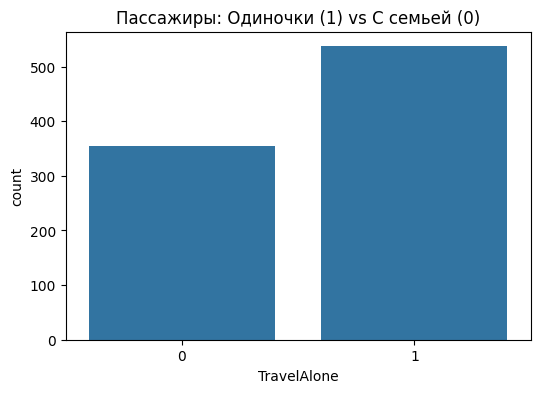

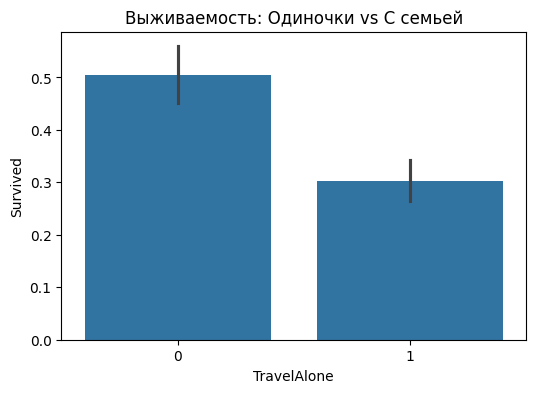

In [142]:
# Количество пассажиров TravelAlone 
plt.figure(figsize=(6, 4))
sns.countplot(x='TravelAlone', data=train_df)
plt.title('Пассажиры: Одиночки (1) vs С семьей (0)')
plt.show()

# Влияние TravelAlone на выживаемость 
plt.figure(figsize=(6, 4))
sns.barplot(x='TravelAlone', y='Survived', data=train_df)
plt.title('Выживаемость: Одиночки vs С семьей')
plt.show()

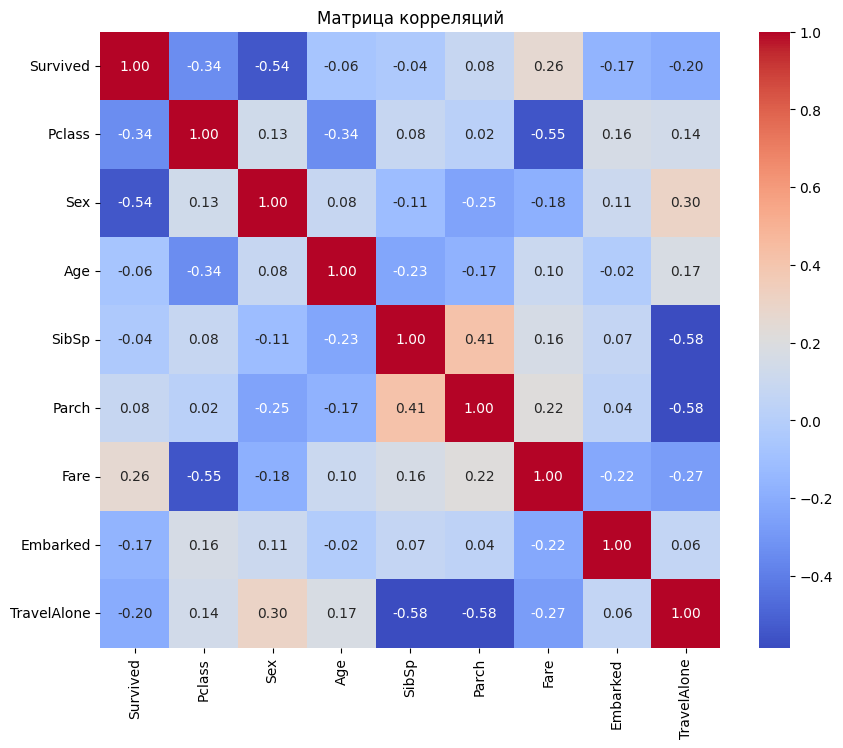

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,TravelAlone
0,0,3,1,22.0,1,0,7.2500,2,0
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,2,1
3,1,1,0,35.0,1,0,53.1000,2,0
4,0,3,1,35.0,0,0,8.0500,2,1


In [143]:
le = LabelEncoder()
train_df['Sex'] = le.fit_transform(train_df['Sex'])
train_df['Embarked'] = le.fit_transform(train_df['Embarked'])
# Матрица корреляций 
# numeric_only=True нужен, так как Sex и Embarked все еще строки
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()
train_df.head()

In [144]:
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Разделение данных на признаки и целевую переменную
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42)
}

results = {}
best_model_name = ""
best_accuracy = 0

# Обучение и оценка 
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    # Сохраняем лучшую модель
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n" + "="*30 + "\n")

print(f"Лучшая модель: {best_model_name} с точностью {best_accuracy:.4f}")

--- Random Forest ---
Accuracy: 0.8268
Confusion Matrix:
[[91 14]
 [17 57]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



--- K-Nearest Neighbors ---
Accuracy: 0.7039
Confusion Matrix:
[[87 18]
 [35 39]]
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.83      0.77       105
           1       0.68      0.53      0.60        74

    accuracy                           0.70       179
   macro avg       0.70      0.68      0.68       179
weighted avg       0.70      0.70      0.70       179



--- Gradient Boosting ---
Accuracy: 0.8156
Confusion Matrix:
[[95 10]
 [23 51]]
Classification Report:
              precision    recall  

In [145]:
from sklearn.model_selection import GridSearchCV
# Словари параметров для каждой возможной модели 
param_grids = {
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10]
    },
    "K-Nearest Neighbors": {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    "Bagging": {
        'n_estimators': [10, 50, 100],
        'max_samples': [0.5, 1.0],
        'max_features': [0.5, 1.0]
    }
}

# Выбор параметров для победителя
current_params = param_grids[best_model_name]
base_model = models[best_model_name]

print(f"Запуск GridSearchCV для модели: {best_model_name}...")

# Поиск по сетке 
grid_search = GridSearchCV(estimator=base_model, 
                           param_grid=current_params, 
                           cv=5, 
                           scoring='accuracy', 
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print(f"Лучшие параметры для {best_model_name}:", grid_search.best_params_)
print("Лучшая точность (на кросс-валидации):", grid_search.best_score_)

# Сохраняем финальную лучшую модель
final_model = grid_search.best_estimator_

Запуск GridSearchCV для модели: Random Forest...
Лучшие параметры для Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Лучшая точность (на кросс-валидации): 0.8271742342164877


In [146]:

test_ids = test_df['PassengerId']

print(test_df.isnull().sum())


test_df['Age'].fillna(train_df['Age'].median(), inplace=True) 
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)
if 'Cabin' in test_df.columns:
    test_df.drop('Cabin', axis=1, inplace=True)

# 2. Удаление лишнего
test_df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True, errors='ignore')

test_df['TravelAlone'] = np.where((test_df['SibSp'] + test_df['Parch']) > 0, 0, 1)

# Используем map, чтобы значения точно совпали с теми, что были при обучении (LabelEncoder)
sex_mapping = {'female': 0, 'male': 1}
test_df['Sex'] = test_df['Sex'].map(sex_mapping)

# Если в Embarked есть новые пропуски в тесте, заполним модой из train
test_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True) 

all_embarked = pd.concat([pd.Series(['C', 'Q', 'S']), test_df['Embarked'].astype(str)]).unique()
le.fit(all_embarked) 
test_df['Embarked'] = le.transform(test_df['Embarked'].astype(str))

# Прогноз 
predictions = final_model.predict(test_df)

# Вывод результатов
output = pd.DataFrame({'PassengerId': test_ids, 'Survived': predictions})
print("Готово! Первые 5 строк прогноза:")
print(output.head())

# Сохранение в файл
output.to_csv('titanic_submission.csv', index=False)

output.groupby('Survived').size()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
Готово! Первые 5 строк прогноза:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


Survived
0    284
1    134
dtype: int64